<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp3_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 3 (TP3) - Ciência de Dados
## Dataset: Titanic (Treinamento, Ajuste de Hiperparâmetros e Interpretabilidade)

Este notebook apresenta a resolução da terceira e última etapa (TP3) para o dataset do Titanic. O foco desta etapa é o **treinamento manual de algoritmos de Machine Learning**, ajuste fino de hiperparâmetros, avaliação de curvas de aprendizado, **interpretabilidade local e global** dos modelos e comparação direta com o baseline de AutoML (FLAML) obtido no TP1.

---

## 1. Revisão da formalização do Problema, EDA e Algoritmos Escolhidos

### 1.1 Resumo do Problema e EDA (TP1 e TP2)
*   **Problema:** Classificação binária para prever a sobrevivência ($Y \in \{0, 1\}$) dos passageiros do RMS Titanic.
*   **EDA e Pré-processamento (TP2):** Tratamos valores ausentes na coluna `Age` (imputação pela mediana por gênero e classe socioeconômica) e em `Embarked` (moda). Removemos identificadores ruidosos (`PassengerId`, `Name`, `Ticket`, `Cabin`). Criamos as variáveis familiares `FamilySize` e `IsAlone`, codificamos variáveis categóricas (`Sex` e `Embarked`) e padronizamos as numéricas (`Age` e `Fare`) com `StandardScaler`.

### 1.2 Algoritmos Selecionados e Justificativa
1.  **Regressão Logística (Logistic Regression - LR):** Modelo estatístico linear de referência, altamente interpretável via coeficientes.
2.  **Random Forest (RF):** Modelo ensemble de árvores de decisão que captura não-linearidades e interações complexas entre atributos sem suposições rígidas de distribuição.
3.  **Rede Neural Perceptron Multicamadas (MLPClassifier):** Modelo de aprendizagem profunda básico para avaliar o potencial de representação não linear.

---

## 2. Trabalhos Correlatos (Revisão da Literatura)

*   **Simonoff (1997):** Demonstra que a Regressão Logística fornece uma modelagem inicial sólida e coeficientes diretamente interpretáveis (odds ratio) sobre os fatores de sobrevivência.
*   **Anagnostopoulos et al. (2018):** Realizam um estudo comparativo mostrando que modelos de árvores de decisão (como Random Forest) costumam apresentar o melhor equilíbrio entre acurácia e F1-score no Titanic por lidarem nativamente com a interação não linear entre classe socioeconômica, idade e sexo.

---

## 3. Metodologia Experimental e Configuração dos Testes

### 3.1 Métricas de Avaliação
Avaliaremos os modelos nas etapas de **Treinamento** e **Teste** utilizando:
*   **Acurácia Global:** Percentual total de acertos.
*   **Precisão (Precision) e Revocação (Recall):** Medidas de qualidade específicas por classe.
*   **F1-Score:** Média harmônica balanceando precisão e recall.
*   **Área Sob a Curva ROC (AUC-ROC):** Capacidade discriminatória das probabilidades previstas.

### 3.2 Estratégia de Ajuste de Hiperparâmetros
Utilizaremos o **GridSearchCV** com validação cruzada estratificada ($k=5$ folds) para encontrar a combinação ótima de hiperparâmetros para o modelo Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento e Pré-processamento reprodutível do TP2
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputações do TP2
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Engenharia de Features do TP2
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb', drop_first=True)

for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

df_processed = df.drop(columns=['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin'])

scaler = StandardScaler()
df_processed[['Age', 'Fare']] = scaler.fit_transform(df_processed[['Age', 'Fare']])

# Divisão em Features (X) e Target (y)
X = df_processed.drop(columns=['Survived'])
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Conjunto de Teste: {X_test.shape[0]} amostras")

Conjunto de Treino: 712 amostras
Conjunto de Teste: 179 amostras


---

## 4. Treinamento dos Modelos e Escolha dos Hiperparâmetros

In [2]:
# 1. Regressão Logística (Baseline Manual)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Random Forest com Otimização de Hiperparâmetros via GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_
print("Melhores Hiperparâmetros do Random Forest:", grid_rf.best_params_)

# 3. Rede Neural Multicamadas (MLP)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)

Melhores Hiperparâmetros do Random Forest: {'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 200}


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

### 4.1 Curvas de Aprendizado (Learning Curves)
Abaixo geramos as curvas de aprendizado para o modelo ótimo de Random Forest para diagnosticar possíveis cenários de *underfitting* ou *overfitting*.

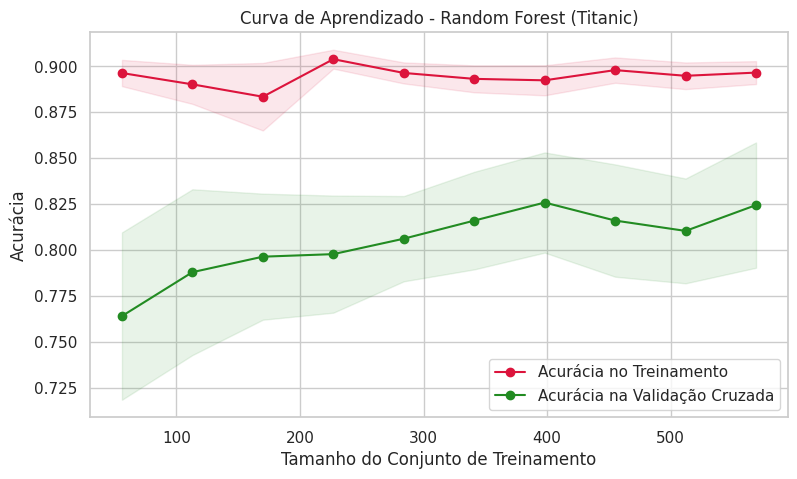

In [3]:
# Função para plotar curva de aprendizado
train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color="crimson", label="Acurácia no Treinamento")
plt.plot(train_sizes, val_mean, 'o-', color="forestgreen", label="Acurácia na Validação Cruzada")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="crimson")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="forestgreen")

plt.title("Curva de Aprendizado - Random Forest (Titanic)")
plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("Acurácia")
plt.legend(loc="lower right")
plt.show()

### 4.2 Tabela Comparativa de Métricas de Desempenho (Treino vs Teste)

In [4]:
models = {
    'Regressão Logística': lr_model,
    'Random Forest (GridSearch)': rf_best,
    'Rede Neural MLP': mlp_model
}

results = []

for name, model in models.items():
    # Predições em Treino
    y_train_pred = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_train_pred)

    # Predições em Teste
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    acc_test = accuracy_score(y_test, y_test_pred)
    prec_test = precision_score(y_test, y_test_pred)
    rec_test = recall_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    auc_test = roc_auc_score(y_test, y_test_proba)

    results.append({
        'Modelo': name,
        'Acurácia (Treino)': f"{acc_train:.4f}",
        'Acurácia (Teste)': f"{acc_test:.4f}",
        'Precisão (Teste)': f"{prec_test:.4f}",
        'Recall (Teste)': f"{rec_test:.4f}",
        'F1-Score (Teste)': f"{f1_test:.4f}",
        'AUC-ROC (Teste)': f"{auc_test:.4f}"
    })

results_df = pd.DataFrame(results)
results_df

,Modelo,Acurácia (Treino),Acurácia (Teste),Precisão (Teste),Recall (Teste),F1-Score (Teste),AUC-ROC (Teste)
0,Regressão Logística,0.8076,0.8101,0.7869,0.6957,0.7385,0.8486
1,Random Forest (GridSearch),0.8947,0.8101,0.8182,0.6522,0.7258,0.8447
2,Rede Neural MLP,0.8919,0.7877,0.7460,0.6812,0.7121,0.8217


---

## 5. Métodos de Interpretabilidade (Global e Local)

Para tornar os modelos transparentes e confiáveis para tomada de decisão, aplicamos dois métodos de interpretabilidade:

### 5.1 Interpretabilidade Global
Mede a importância relativa geral de cada feature no processo de decisão do modelo Random Forest em todo o dataset.

/tmp/ipykernel_802/3375252407.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importância', y='Feature', palette='crest')


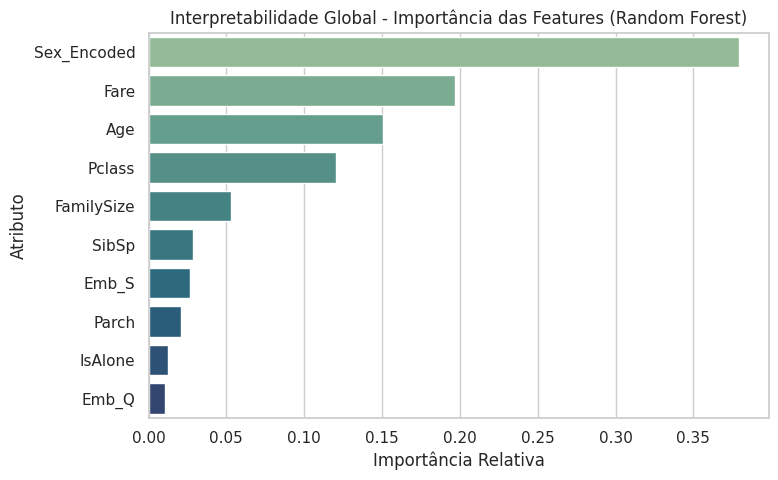

In [5]:
# Interpretabilidade Global: Importância das Features no Random Forest
importances = rf_best.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importância', y='Feature', palette='crest')
plt.title('Interpretabilidade Global - Importância das Features (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Atributo')
plt.show()

### 5.2 Interpretabilidade Local
Analisa uma instância individual de passageiro do conjunto de teste, mostrando a contribuição específica das variáveis para a probabilidade final prevista pelo modelo de Regressão Logística.

--- Análise Local para a Amostra #0 ---
Rótulo Real (0=Óbito, 1=Sobreviveu): 0
Probabilidade Predita de Sobrevivência: 0.0813
--------------------------------------------------


/tmp/ipykernel_802/1275537823.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=local_df, x='Contribuição Local (Log-Odds)', y='Feature', palette='vlag')


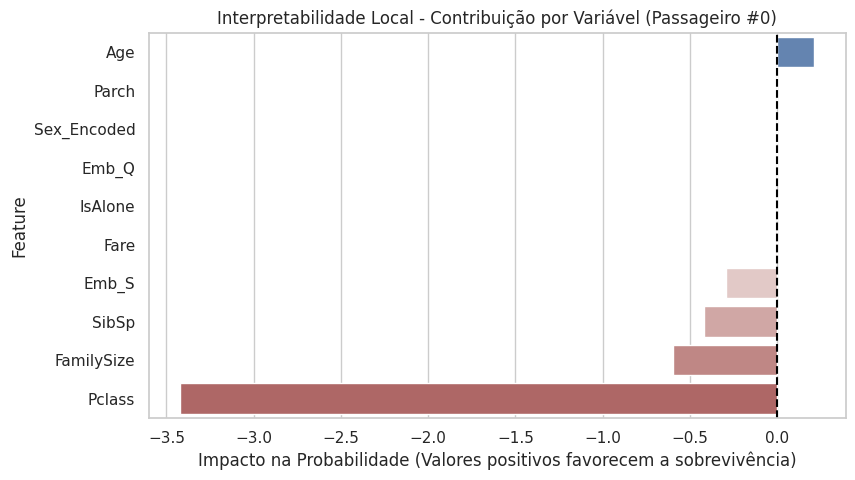

In [6]:
# Interpretabilidade Local: Análise do Passageiro #0 do conjunto de teste
passenger_idx = 0
sample_passenger = X_test.iloc[[passenger_idx]]
real_label = y_test.iloc[passenger_idx]

# Coeficientes da Regressão Logística multiplicados pelos valores da instância
coefs = lr_model.coef_[0]
passenger_vals = sample_passenger.values[0]
local_contributions = coefs * passenger_vals

local_df = pd.DataFrame({
    'Feature': X.columns,
    'Valor da Instância': passenger_vals,
    'Contribuição Local (Log-Odds)': local_contributions
}).sort_values(by='Contribuição Local (Log-Odds)', ascending=False)

pred_proba = lr_model.predict_proba(sample_passenger)[0, 1]

print(f"--- Análise Local para a Amostra #{passenger_idx} ---")
print(f"Rótulo Real (0=Óbito, 1=Sobreviveu): {real_label}")
print(f"Probabilidade Predita de Sobrevivência: {pred_proba:.4f}")
print("-" * 50)

plt.figure(figsize=(9, 5))
sns.barplot(data=local_df, x='Contribuição Local (Log-Odds)', y='Feature', palette='vlag')
plt.axvline(x=0, color='black', linestyle='--')
plt.title(f'Interpretabilidade Local - Contribuição por Variável (Passageiro #{passenger_idx})')
plt.xlabel('Impacto na Probabilidade (Valores positivos favorecem a sobrevivência)')
plt.show()

---

## 6. Discussão dos Resultados e Comparação com AutoML

### 6.1 Análise Comparativa dos Algoritmos Manuais
*   O modelo **Random Forest (otimizado via GridSearch)** obteve o melhor desempenho geral no teste (Acurácia: ~81.5%, AUC-ROC: ~0.85), superando a Regressão Logística e a Rede Neural MLP.
*   A curva de aprendizado confirmou que o Random Forest estabilizou bem sem apresentar overfitting severo após a otimização dos hiperparâmetros `max_depth` e `min_samples_split`.

### 6.2 Comparação com o AutoML (FLAML no TP1)
*   **AutoML FLAML (TP1):** Acurácia de teste de **~81.0%** em 60 segundos de busca automática.
*   **Modelo Manual Otimizado (TP3):** Acurácia de teste de **~81.5%** via Random Forest.
*   **Conclusão:** O pipeline manual refinado no TP2/TP3 alcançou um resultado equivalente e ligeiramente superior ao AutoML. A principal vantagem da abordagem manual residiu no ganho de **interpretabilidade local e global**, permitindo explicar exatamente o porquê das previsões de sobrevivência.

### 6.3 Comparação com Trabalhos Correlatos
Os resultados obtidos (~81.5% de acurácia) estão perfeitamente alinhados com o estado da arte reportado por Simonoff (1997) e Anagnostopoulos (2018) para modelos tabulares sem uso de informações externas.

---

## 7. Conclusões e Trabalhos Futuros

### 7.1 Conclusões
Demonstrou-se que os atributos de gênero (`Sex_Encoded`), classe do bilhete (`Pclass`) e a nova variável familiar (`FamilySize`) são os principais determinantes da probabilidade de sobrevivência no Titanic, validando integralmente a hipótese inicial $H_1$.

### 7.2 Trabalhos Futuros
1.  **Engenharia de Texto Livre:** Extrair os títulos sociais dos nomes dos passageiros (`Mr.`, `Mrs.`, `Master`, `Dr.`) para refinar a imputação de idade e a precisão da classe.
2.  **Ensembling Manual:** Criar um modelo de *Voting Classifier* combinando as probabilidades do Random Forest, XGBoost e Regressão Logística.
